# 03 - Split decision, Character-level model, Clustering, SOTA

Dataset: **PhiUSIIL Phishing URL Dataset** (UCI id 967).
Target is `label`: 1 = legitimate, 0 = phishing. Following NB 02, we
model **phishing as the positive class** so precision / recall / PR-AUC
describe *catching phishing*.

NB 01 established the leakage-clean feature set and split conventions;
NB 02 built the tabular models (LR / RF / XGBoost) and saved their
metrics. This notebook:

1. reloads the data and NB 01's feature manifest
2. settles the train/test grouping convention (registered-domain vs.
   exact `Domain`) and locks it to NB 02's for comparability
3. trains a **character-level CNN on the raw URL string only** — the
   leakage-immune "hard mode" comparison point
4. clusters the phishing-only rows into attack "families"
5. assembles the SOTA comparison table

The overall project is described in the repository `README.md`.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Section-specific heavy deps (torch, tldextract, hdbscan, rapidfuzz)
# are imported at the top of their own sections to keep setup light.

DATA_PATH = Path("../data/phiusiil.csv")
MANIFEST_PATH = Path("../data/01_feature_columns.json")

In [3]:
df = pd.read_csv(DATA_PATH)
manifest = json.loads(MANIFEST_PATH.read_text())

target = manifest["target"]
clean_features = manifest["clean_numeric_features"]
group_col = manifest["split_group_column"]

# Same pre-split cleaning NB 02 uses, so our numbers are comparable.
# We keep URL and Domain as columns (raw material for the char model,
# engineered features and grouping) even though they're not features.
if manifest["drop_duplicate_urls"]:
    before = len(df)
    df = df.drop_duplicates(subset="URL").reset_index(drop=True)
    print(f"dropped {before - len(df)} duplicate-URL rows")

y = df[target]

print(f"rows: {len(df):,}")
print(f"clean feature count: {len(clean_features)}")
print(f"group column for splits: {group_col}")

dropped 425 duplicate-URL rows
rows: 235,370
clean feature count: 49
group column for splits: Domain


## Registered-domain grouping decision

NB 01 split on the exact `Domain` string and flagged that this
*under*-groups subdomains: `ipfs.io`, `gateway.ipfs.io` and
`cf-ipfs.com` are the same service but count as three domains, so
related rows can still land on both sides of a train/test split. The
stricter alternative groups by **registered domain** (eTLD+1 via
`tldextract`), which collapses those into one group.

This matters because the char-model, the clustering, and NB 02's
tabular models must all use the *same* split, or the SOTA table
compares numbers produced under different conditions. Here we measure
how much stricter grouping changes (a) the group count and (b) a quick
logistic-regression score, then pick one convention and tell the team.

In [4]:
import tldextract

# eTLD+1, e.g. "gateway.ipfs.io" -> "ipfs.io". Uses a bundled public
# suffix list; suppress the network refresh for reproducibility.
extractor = tldextract.TLDExtract(suffix_list_urls=())


def registered_domain(host: str) -> str:
    ext = extractor(str(host))
    # fall back to the raw host for IP-address URLs (no eTLD+1)
    return ext.top_domain_under_public_suffix or str(host)


df["RegDomain"] = df["Domain"].map(registered_domain)

n_exact = df["Domain"].nunique()
n_reg = df["RegDomain"].nunique()
print(f"exact Domain groups:     {n_exact:,}")
print(f"registered-domain groups: {n_reg:,}")
print(f"collapsed by {n_exact - n_reg:,} groups")
print()
# how many rows share a registered domain with another row?
reg_counts = df["RegDomain"].value_counts()
reg_repeated = reg_counts[reg_counts > 1]
print(
    f"rows sharing a registered domain: "
    f"{reg_repeated.sum():,} ({reg_repeated.sum() / len(df):.1%})"
)
reg_counts.head(10)

exact Domain groups:     220,086
registered-domain groups: 175,509
collapsed by 44,577 groups

rows sharing a registered domain: 65,825 (28.0%)


RegDomain
web.app            5718
firebaseapp.com    5546
repl.co            3746
weeblysite.com     3079
ipfs.io            1552
workers.dev        1423
square.site        1187
dweb.link           959
xsph.ru             928
pantheonsite.io     891
Name: count, dtype: int64

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler


def quick_logreg(X, y, groups):
    """Basic logistic regression under a grouped split; return acc, F1."""
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    model = LogisticRegression(max_iter=1000, class_weight="balanced")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds), f1_score(y_test, preds)


X = df[clean_features]
acc_exact, f1_exact = quick_logreg(X, y, groups=df["Domain"])
acc_reg, f1_reg = quick_logreg(X, y, groups=df["RegDomain"])

print(f"exact-Domain split:      acc={acc_exact:.4f}  f1={f1_exact:.4f}")
print(f"registered-domain split: acc={acc_reg:.4f}  f1={f1_reg:.4f}")

exact-Domain split:      acc=0.9995  f1=0.9996
registered-domain split: acc=0.9990  f1=0.9992


In [6]:
# optional: treat multi-tenant PaaS suffixes as public, so
# victim-a.web.app and victim-b.web.app become separate groups
extractor_strict = tldextract.TLDExtract(
    suffix_list_urls=(), include_psl_private_domains=True
)
df["RegDomainStrict"] = df["Domain"].map(
    lambda h: extractor_strict(str(h)).top_domain_under_public_suffix or str(h)
)
print(f"strict (PaaS-aware) groups: {df['RegDomainStrict'].nunique():,}")

strict (PaaS-aware) groups: 197,709


In [7]:
acc_strict, f1_strict = quick_logreg(X, y, groups=df["RegDomainStrict"])
print(f"PaaS-aware split: acc={acc_strict:.4f}  f1={f1_strict:.4f}")

PaaS-aware split: acc=0.9993  f1=0.9994


**Decision.** Three grouping strictnesses, same quick logistic model:

| Grouping | Groups | acc | F1 |
|---|---|---|---|
| exact `Domain` (NB 01 / NB 02) | 220,086 | 0.9995 | 0.9996 |
| PaaS-aware eTLD+1 (PSL-private on) | 197,709 | 0.9993 | 0.9994 |
| naive eTLD+1 | 175,509 | 0.9990 | 0.9992 |

Accuracy is essentially invariant (0.9990–0.9995) across a 44,577-group
range of strictness. The drop is monotonic with strictness — the
direction leakage would predict — but negligible in size, reinforcing
NB 01's finding that the dataset is easy regardless of how
conservatively the split is drawn.

Because the score is grouping-invariant, we **adopt NB 02's exact
`Domain` grouping** (`GroupShuffleSplit`, `test_size=0.2`,
`random_state=42`) rather than reworking it. This makes the char
model below share NB 02's exact test set, so the SOTA table compares
numbers produced under identical conditions. The stricter
registered-domain analysis above is retained as evidence that this
choice doesn't inflate our results.

## Character-level model on the raw URL

The tabular models in NB 02 use page-content and lexical features that
make PhiUSIIL trivially easy (~99.9%). This model sees only the raw URL
string: no engineered features, no page content, no `URLSimilarityIndex`.
It cannot leak, because it has access to nothing but the characters of
the URL itself, so it is the leakage-immune comparison point for the
URL-only lexical literature (Sahingoz et al., 2019, reached 97.98% with
an NLP-feature Random Forest; see the SOTA comparison below).

We tokenize each URL at the character level, embed, and pass it through
a small 1-D CNN with a sigmoid output, trained with class weights on the
same exact-`Domain` split used in NB 02 so the numbers are comparable.

In [8]:
# Build a character vocabulary from the training URLs only (fit on
# train to avoid leaking test-set characters into the vocab). Reserve
# 0 for padding and 1 for unknown/out-of-vocab characters.
MAX_LEN = 200  # covers ~99th pct of URL lengths; longer URLs truncated

urls = df["URL"].astype(str).values
labels = df[target].values

lengths = np.array([len(u) for u in urls])
print(
    f"URL length: median={np.median(lengths):.0f}  "
    f"95th={np.percentile(lengths, 95):.0f}  "
    f"99th={np.percentile(lengths, 99):.0f}  max={lengths.max()}"
)
print(
    f"URLs longer than MAX_LEN={MAX_LEN}: "
    f"{(lengths > MAX_LEN).sum()} ({(lengths > MAX_LEN).mean():.2%})"
)

URL length: median=28  95th=74  99th=145  max=6097
URLs longer than MAX_LEN=200: 1427 (0.61%)


In [9]:
from collections import Counter


# Phishing = positive, matching NB 02. df is already dup-URL-dropped and
# index-reset (Section 1), so this split reproduces NB 02's test set.
y_phish = (1 - df[target]).to_numpy()
groups = df["Domain"].to_numpy()
urls = df["URL"].astype(str).to_numpy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, y_phish, groups=groups))

url_train, url_test = urls[train_idx], urls[test_idx]
y_train, y_test = y_phish[train_idx], y_phish[test_idx]

print(f"train: {len(train_idx):,}   test: {len(test_idx):,}")
print(f"phishing rate  train={y_train.mean():.3f}  test={y_test.mean():.3f}")

# Character vocabulary, fit on TRAIN urls only. 0 = <pad>, 1 = <unk>.
char_counts = Counter()
for u in url_train:
    char_counts.update(u)

MIN_FREQ = 5  # chars rarer than this in train collapse to <unk>
vocab = {"<pad>": 0, "<unk>": 1}
for ch, cnt in char_counts.most_common():
    if cnt >= MIN_FREQ:
        vocab[ch] = len(vocab)

print(f"distinct chars in train: {len(char_counts)}")
print(f"vocab size (>= {MIN_FREQ} occ, + pad/unk): {len(vocab)}")

train: 188,738   test: 46,632
phishing rate  train=0.428  test=0.423
distinct chars in train: 71
vocab size (>= 5 occ, + pad/unk): 67


In [10]:
def encode(url, vocab, max_len=MAX_LEN):
    ids = [vocab.get(c, 1) for c in url[:max_len]]  # 1 = <unk>
    ids += [0] * (max_len - len(ids))  # 0 = <pad>
    return ids


X_train_ids = np.array([encode(u, vocab) for u in url_train], dtype=np.int64)
X_test_ids = np.array([encode(u, vocab) for u in url_test], dtype=np.int64)

trunc = (np.array([len(u) for u in url_train]) > MAX_LEN).mean()
print(f"X_train_ids: {X_train_ids.shape}   X_test_ids: {X_test_ids.shape}")
print(f"train URLs truncated at {MAX_LEN}: {trunc:.2%}")
print("example row (first 40 ids):", X_train_ids[0][:40])

X_train_ids: (188738, 200)   X_test_ids: (46632, 200)
train URLs truncated at 200: 0.61%
example row (first 40 ids): [11  2  2  7  6 17  4  4  3  3  3  5  6  8 20  2 11 22 10 16 26 15  8  6
 10 13 12  6  5 12  8 15  0  0  0  0  0  0  0  0]


### Architecture

A compact character-level CNN (Kim, 2014, adapted to characters):

- Embedding: each character id maps to a 48-d vector (`padding_idx=0`).
- Three parallel 1-D convolutions, kernel widths 3 / 5 / 7 (128 filters
  each), reading character 3-, 5-, and 7-grams.
- Global max-pool over position, then concatenate the three widths.
- Dropout (0.4), a linear layer, and a single logit. Loss is
  `BCEWithLogitsLoss` with `pos_weight = n_neg/n_pos` for class weighting.

A grouped 10% validation slice (domains do not straddle train/val) is
used only to monitor convergence and keep the best-PR-AUC epoch. The test
set is untouched until evaluation.

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"device: {device}")

# Inner grouped train/val split; val only monitors convergence / early
# stopping. Grouped so no domain straddles train and val either.
groups_train = groups[train_idx]
inner = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
tr_i, va_i = next(inner.split(X_train_ids, y_train, groups=groups_train))

Xtr = torch.tensor(X_train_ids[tr_i], dtype=torch.long)
ytr = torch.tensor(y_train[tr_i], dtype=torch.float32)
Xva = torch.tensor(X_train_ids[va_i], dtype=torch.long)
yva = torch.tensor(y_train[va_i], dtype=torch.float32)
Xte = torch.tensor(X_test_ids, dtype=torch.long)
yte = torch.tensor(y_test, dtype=torch.float32)

BATCH = 512
train_loader = DataLoader(
    TensorDataset(Xtr, ytr), batch_size=BATCH, shuffle=True
)
val_loader = DataLoader(TensorDataset(Xva, yva), batch_size=BATCH)
test_loader = DataLoader(TensorDataset(Xte, yte), batch_size=BATCH)

# class weight for phishing (positive): n_neg / n_pos on the train split
n_pos = float(ytr.sum())
n_neg = float(len(ytr) - ytr.sum())
pos_weight = torch.tensor([n_neg / n_pos], device=device)
print(
    f"train/val: {len(tr_i):,}/{len(va_i):,}   pos_weight={n_neg / n_pos:.3f}"
)


class CharCNN(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=48,
        n_filters=128,
        kernels=(3, 5, 7),
        dropout=0.4,
    ):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(embed_dim, n_filters, k, padding=k // 2)
                for k in kernels
            ]
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(kernels), 1)

    def forward(self, x):
        e = self.embed(x).permute(0, 2, 1)  # (B, embed, L)
        feats = [
            F.relu(conv(e)).max(dim=2).values  # global max-pool
            for conv in self.convs
        ]
        h = self.dropout(torch.cat(feats, dim=1))
        return self.fc(h).squeeze(1)  # (B,) logits


model = CharCNN(vocab_size=len(vocab)).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"model params: {n_params:,}")

device: mps
train/val: 170,359/18,379   pos_weight=1.326
model params: 96,145


In [12]:
from sklearn.metrics import average_precision_score

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 6


@torch.no_grad()
def predict_proba(loader):
    model.eval()
    probs = []
    for xb, _ in loader:
        logits = model(xb.to(device))
        probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs)


best_val_ap, best_state = -1.0, None
for epoch in range(1, EPOCHS + 1):
    model.train()
    total = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(xb)
    train_loss = total / len(Xtr)

    val_p = predict_proba(val_loader)
    val_ap = average_precision_score(yva.numpy(), val_p)
    val_f1 = f1_score(yva.numpy(), (val_p >= 0.5).astype(int))
    flag = ""
    if val_ap > best_val_ap:
        best_val_ap = val_ap
        best_state = {
            k: v.detach().cpu().clone() for k, v in model.state_dict().items()
        }
        flag = "  <- best"
    print(
        f"epoch {epoch}  train_loss={train_loss:.4f}  "
        f"val_PR_AUC={val_ap:.4f}  val_F1={val_f1:.4f}{flag}"
    )

model.load_state_dict(best_state)
print(f"\nrestored best val PR-AUC = {best_val_ap:.4f}")

epoch 1  train_loss=0.0455  val_PR_AUC=0.9988  val_F1=0.9970  <- best
epoch 2  train_loss=0.0164  val_PR_AUC=0.9988  val_F1=0.9970  <- best
epoch 3  train_loss=0.0156  val_PR_AUC=0.9988  val_F1=0.9970  <- best
epoch 4  train_loss=0.0142  val_PR_AUC=0.9989  val_F1=0.9972  <- best
epoch 5  train_loss=0.0134  val_PR_AUC=0.9989  val_F1=0.9973
epoch 6  train_loss=0.0126  val_PR_AUC=0.9989  val_F1=0.9972  <- best

restored best val PR-AUC = 0.9989


model        CharCNN (URL only)
accuracy               0.998499
precision              0.999898
recall                  0.99655
f1                     0.998221
roc_auc                0.999094
pr_auc                  0.99927


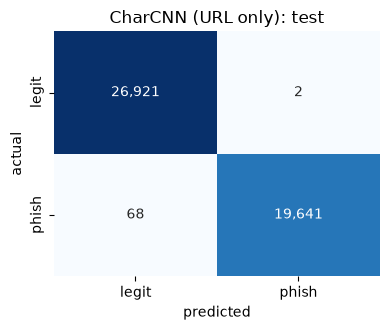

In [13]:
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)

test_proba = predict_proba(test_loader)
test_pred = (test_proba >= 0.5).astype(int)

char_result = {
    "model": "CharCNN (URL only)",
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred),
    "recall": recall_score(y_test, test_pred),
    "f1": f1_score(y_test, test_pred),
    "roc_auc": roc_auc_score(y_test, test_proba),
    "pr_auc": average_precision_score(y_test, test_proba),
}
print(pd.Series(char_result).to_string())

cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(4, 3.4))
sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=["legit", "phish"],
    yticklabels=["legit", "phish"],
)
plt.title("CharCNN (URL only): test")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.tight_layout()
plt.show()

### Findings

The model converged in one epoch (val PR-AUC 0.9988 at epoch 1). On the
held-out test set:

| metric | CharCNN (URL only) | tuned XGBoost (NB 02) |
|---|---|---|
| accuracy | 0.9985 | ~0.999 |
| precision (phishing) | 0.9999 | ~0.999 |
| recall (phishing) | 0.9965 | ~0.999 |
| PR-AUC | 0.9993 | ~0.999 |

At threshold 0.5 it makes 1 false positive and 69 false negatives on
46,632 test URLs.

The URL-only model does not come in harder than the tabular models. It
essentially ties them and lands above the URL-only lexical literature
(Sahingoz et al., 2019: 97.98%; the char-CNN band in the SOTA
comparison: 97-99%). So PhiUSIIL's separability is not confined to the
page-content columns NB 01 flagged; it is present in the raw URL strings
themselves. Legitimate and phishing URLs here come from systematically
different sources (well-known registrable domains vs. IP-address hosts,
IPFS gateways, PaaS subdomains, randomized tokens), differences visible
character by character. This is our own evidence for the
benchmark-leakage critique in the SOTA comparison (Dalton et al., 2025;
Das et al., 2019).

Two caveats for the SOTA table. First, this model beats the URL-only
literature because PhiUSIIL is more separable than the cross-source
corpora those papers used, not because the architecture is stronger; the
claim is "~99.85% on PhiUSIIL," not a general result. Second, the
exact-`Domain` split still lets registered-domain siblings on shared
platforms (`web.app`, `firebaseapp.com`, `repl.co`) fall on both sides,
which a character model could exploit as platform-level memorization. The
grouping analysis above showed the tabular score is near-invariant to
this (0.9993 PaaS-aware vs. 0.9995 exact), so it is unlikely to be the
main driver, but the CNN is more exposed to it than logistic regression.

## Clustering: phishing attack families

The models so far are supervised. This section adds an unsupervised
method, the project's second algorithm type, and asks a different
question: not whether a URL is phishing, but what kinds of phishing are
in the data.

We cluster the phishing rows only on NB 01's leakage-clean feature set
(label held out) and profile the groups as attack "families." This is
standard in the phishing literature (Feng et al., 2022, clustered
phishing kits; Althobaiti et al., 2023, clustered campaigns; Zia &
Kalidass, 2025, clustered lexical URL tokens; see the SOTA comparison).
Cluster IDs are not fed back into the classifier, to avoid a second
leakage-review cycle.

Method: KMeans with k chosen by elbow and silhouette, centroid profiling
to name the families, PCA for a 2-D view, and HDBSCAN as a density-based
cross-check.

In [14]:
# Cluster the PHISHING rows only, on the leakage-clean feature set from
# NB 01 (label held out). Goal: find structure within phishing,
# "attack families", not to separate phishing from legit.
phish_mask = (df[target] == 0).to_numpy()
Xp_raw = df.loc[phish_mask, clean_features].copy()

# Drop zero-variance columns within the phishing subset (constant here,
# so they carry no clustering signal and would clutter the profile).
nunique = Xp_raw.nunique()
const_cols = nunique[nunique <= 1].index.tolist()
Xp_raw = Xp_raw.drop(columns=const_cols)
cluster_features = Xp_raw.columns.tolist()

scaler = StandardScaler()
Xp = scaler.fit_transform(Xp_raw)

print(f"phishing rows: {Xp.shape[0]:,}")
print(
    f"clustering features: {Xp.shape[1]} "
    f"(dropped {len(const_cols)} constant: {const_cols})"
)

phishing rows: 100,520
clustering features: 49 (dropped 0 constant: [])


k=2  inertia=4,500,166  silhouette=0.4373
k=3  inertia=4,248,341  silhouette=0.1302
k=4  inertia=3,923,595  silhouette=0.1493
k=5  inertia=3,736,818  silhouette=0.1540
k=6  inertia=3,576,639  silhouette=0.0893
k=7  inertia=3,427,474  silhouette=0.0938
k=8  inertia=3,281,426  silhouette=0.1008
k=9  inertia=3,171,685  silhouette=0.1207
k=10  inertia=3,074,064  silhouette=0.1136


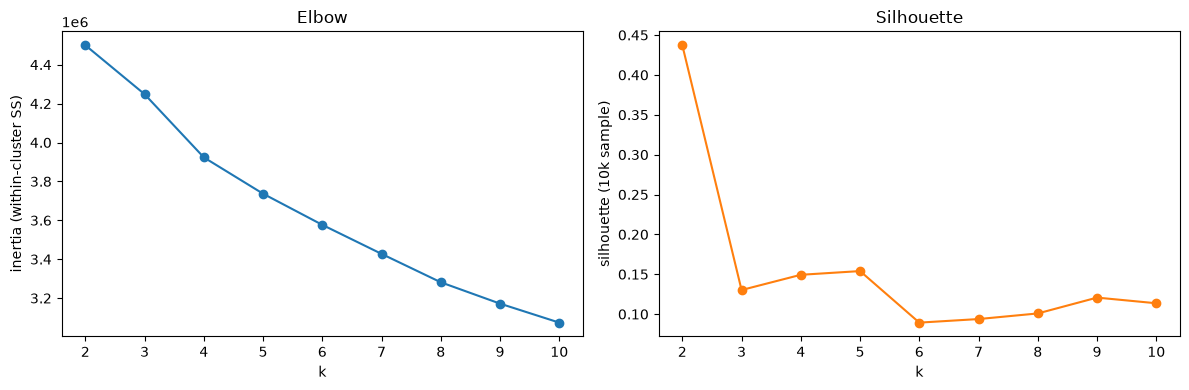

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 11)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    lbl = km.fit_predict(Xp)
    inertias.append(km.inertia_)
    # silhouette on a subsample; full O(n^2) is infeasible at ~100k rows
    sil = silhouette_score(Xp, lbl, sample_size=10000, random_state=42)
    silhouettes.append(sil)
    print(f"k={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(ks), inertias, "o-", color="tab:blue")
ax1.set_xlabel("k")
ax1.set_ylabel("inertia (within-cluster SS)")
ax1.set_title("Elbow")
ax2.plot(list(ks), silhouettes, "o-", color="tab:orange")
ax2.set_xlabel("k")
ax2.set_ylabel("silhouette (10k sample)")
ax2.set_title("Silhouette")
plt.tight_layout()
plt.show()

### Choosing k

| k | inertia | silhouette (10k) |
|---|---|---|
| 2 | 4,500,166 | 0.437 |
| 3 | 4,248,341 | 0.130 |
| 4 | 3,923,595 | 0.149 |
| 5 | 3,736,818 | 0.154 |
| 6-10 | 3.58M-3.07M | 0.089-0.121 |

k=2 has by far the highest silhouette (0.44): the strongest structure is
a single binary split, matching NB 01's finding that phishing pages
divide into content-less shells vs. content-bearing pages. The elbow is
otherwise soft, typical of high-dimensional tabular data with correlated
features.

k=2 is too coarse for a families deliverable, so we use k=5, the
silhouette peak among k>=3 and where the elbow flattens. We report the
k=2 split as the dominant coarse structure and profile k=5 as
interpretable strata. The silhouettes at k=5 (~0.15) are low, so these
are overlapping descriptive families rather than crisply separated
clusters; HDBSCAN below checks how much crisp density structure exists.

In [16]:
K_FAMILIES = 5

# Dominant structure is binary (k=2, silhouette 0.44); characterize it
# briefly, then use k=5 for interpretable families.
km2 = KMeans(n_clusters=2, n_init=10, random_state=42).fit(Xp)
sizes2 = pd.Series(km2.labels_).value_counts().sort_index()
print("k=2 dominant split sizes:")
for c, n in sizes2.items():
    print(f"  cluster {c}: {n:,} ({n / len(Xp):.1%})")

km5 = KMeans(n_clusters=K_FAMILIES, n_init=10, random_state=42)
phish_labels = km5.fit_predict(Xp)

profile = Xp_raw.copy()
profile["cluster"] = phish_labels
sizes = pd.Series(phish_labels).value_counts().sort_index()
print(f"\nk={K_FAMILIES} family sizes:")
for c, n in sizes.items():
    print(f"  cluster {c}: {n:,} ({n / len(Xp):.1%})")

# Interpretable raw-unit profile (only columns present in the feature set)
shortlist = [
    "IsDomainIP",
    "IsHTTPS",
    "URLLength",
    "DomainLength",
    "NoOfSubDomain",
    "DegitRatioInURL",
    "SpacialCharRatioInURL",
    "LineOfCode",
    "NoOfJS",
    "NoOfImage",
    "NoOfExternalRef",
    "NoOfCSS",
    "HasSocialNet",
    "HasCopyrightInfo",
    "HasDescription",
    "HasPasswordField",
    "HasSubmitButton",
    "TLDLegitimateProb",
]
shortlist = [c for c in shortlist if c in cluster_features]
means = profile.groupby("cluster")[shortlist].mean().T
means.columns = [f"c{c}" for c in means.columns]
print(f"\nper-cluster mean (raw units), {len(shortlist)} features:")
print(means.round(2).to_string())

k=2 dominant split sizes:
  cluster 0: 13,086 (13.0%)
  cluster 1: 87,434 (87.0%)

k=5 family sizes:
  cluster 0: 68,743 (68.4%)
  cluster 1: 5 (0.0%)
  cluster 2: 1,133 (1.1%)
  cluster 3: 11,809 (11.7%)
  cluster 4: 18,830 (18.7%)

per-cluster mean (raw units), 18 features:
                          c0       c1      c2      c3     c4
IsDomainIP              0.00     0.00    0.39    0.00   0.00
IsHTTPS                 0.52     0.80    0.79    0.79   0.17
URLLength              42.59  4128.40  310.58   67.42  26.42
DomainLength           25.87    24.80   22.94   27.92  17.16
NoOfSubDomain           1.29     0.20    1.67    1.06   0.76
DegitRatioInURL         0.07     0.46    0.18    0.11   0.02
SpacialCharRatioInURL   0.09     0.18    0.12    0.10   0.06
LineOfCode             40.61   465.80  153.70  267.33  24.94
NoOfJS                  0.25    10.60    1.35    5.30   0.41
NoOfImage               0.19     1.80    2.06    5.77   0.18
NoOfExternalRef         0.77    16.80    1.60    3.9

In [17]:
# KMeans centroids live in standardized space, so each value is that
# cluster's mean in SDs from the phishing-wide mean. Large |z| = what
# makes the family distinctive.
centroids = pd.DataFrame(km5.cluster_centers_, columns=cluster_features)
for c in range(K_FAMILIES):
    row = centroids.loc[c]
    top = row.reindex(row.abs().sort_values(ascending=False).index).head(6)
    print(f"cluster {c} (n={sizes[c]:,}), top distinguishing features:")
    for feat, z in top.items():
        arrow = "↑" if z > 0 else "↓"
        print(f"    {feat:24s} {z:+.2f} {arrow}")
    print()

cluster 0 (n=68,743), top distinguishing features:
    URLTitleMatchScore       -0.48 ↓
    DomainTitleMatchScore    -0.44 ↓
    HasTitle                 -0.30 ↓
    HasSubmitButton          -0.26 ↓
    HasHiddenFields          -0.24 ↓
    HasPasswordField         -0.21 ↓

cluster 1 (n=5), top distinguishing features:
    NoOfObfuscatedChar       +133.83 ↑
    NoOfEqualsInURL          +113.12 ↑
    NoOfDegitsInURL          +106.02 ↑
    NoOfAmpersandInURL       +100.09 ↑
    NoOfOtherSpecialCharsInURL +88.90 ↑
    URLLength                +66.65 ↑

cluster 2 (n=1,133), top distinguishing features:
    HasObfuscation           +6.01 ↑
    IsDomainIP               +4.84 ↑
    ObfuscationRatio         +4.78 ↑
    URLLength                +4.32 ↑
    NoOfLettersInURL         +4.20 ↑
    NoOfQMarkInURL           +4.09 ↑

cluster 3 (n=11,809), top distinguishing features:
    HasSubmitButton          +1.75 ↑
    HasHiddenFields          +1.69 ↑
    HasPasswordField         +1.52 ↑
    NoOfIm

### The five families

Each cluster's raw-unit means and its centroid's top distinguishing
features (in SDs from the phishing-wide mean) give the following:

| Cluster | Size | Defining signature | Attack family |
|---|---|---|---|
| c0 | 68,743 (68.4%) | No title, no forms, ~40 lines of code, low title-match | Empty-shell pages (parked/stub, no real content) |
| c3 | 11,809 (11.7%) | Password, submit, hidden fields, images, CSS, favicon, ~267 lines of code | Credential-harvesting forms (fake logins) |
| c4 | 18,830 (18.7%) | Title matches domain, short clean URLs, only 17% HTTPS | HTTP lookalike stubs (brand-consistent, plain HTTP) |
| c2 | 1,133 (1.1%) | `HasObfuscation`, 39% IP-hosted, long URLs, many `?` params | IP-host / obfuscated-URL pages |
| c1 | 5 (0.0%) | URL length ~4,128 chars, extreme obfuscated/digit/ampersand counts | Outlier micro-cluster (ultra-long parameter-stuffed URLs) |

Empty-shell pages dominate at 68%, consistent with NB 01's finding that
most phishing rows are content-less and with the k=2 super-split (87/13)
that separates these from content-bearing pages. The two active attack
types separate cleanly: credential-harvesting forms (c3), with the
password/submit/hidden-field signature of a fake login, and HTTP lookalike
stubs (c4), which look brand-consistent but lack HTTPS.

Cluster c1 holds only 5 rows. KMeans minimizes squared distance and is
sensitive to outliers, so a few 4,000-character URLs captured their own
centroid. This is a KMeans artifact, not a real family; the HDBSCAN
cross-check below should relabel these as noise.

PC1+PC2 explained variance: 13.6% + 9.3% = 22.9%


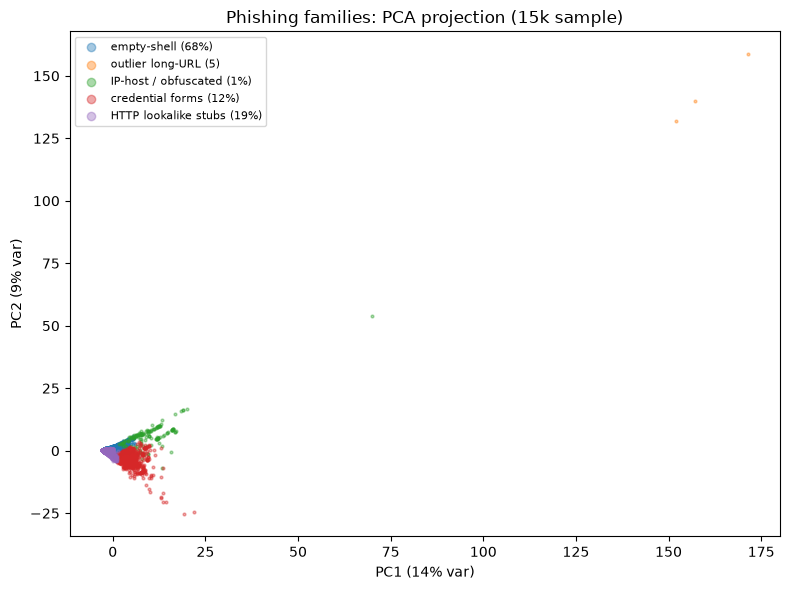

In [18]:
from sklearn.decomposition import PCA

FAMILY_NAMES = {
    0: "empty-shell (68%)",
    1: "outlier long-URL (5)",
    2: "IP-host / obfuscated (1%)",
    3: "credential forms (12%)",
    4: "HTTP lookalike stubs (19%)",
}

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(Xp)
ev = pca.explained_variance_ratio_
print(
    f"PC1+PC2 explained variance: {ev[0]:.1%} + {ev[1]:.1%} = {ev.sum():.1%}"
)

# Subsample for a readable scatter; fit was on all rows.
rng = np.random.default_rng(42)
idx = rng.choice(len(coords), size=min(15000, len(coords)), replace=False)

plt.figure(figsize=(8, 6))
for c in range(K_FAMILIES):
    m = phish_labels[idx] == c
    plt.scatter(
        coords[idx][m, 0],
        coords[idx][m, 1],
        s=4,
        alpha=0.4,
        label=FAMILY_NAMES[c],
    )
plt.xlabel(f"PC1 ({ev[0]:.0%} var)")
plt.ylabel(f"PC2 ({ev[1]:.0%} var)")
plt.title("Phishing families: PCA projection (15k sample)")
plt.legend(markerscale=3, fontsize=8, loc="best")
plt.tight_layout()
plt.show()

In [19]:
from sklearn.cluster import HDBSCAN

# Density-based cross-check on a subsample (HDBSCAN is heavier than
# KMeans). Unlike KMeans it doesn't force every point into a cluster;
# it can label sparse outliers as noise (-1), which is the honest test
# of how much crisp structure exists and whether the 5-row KMeans
# micro-cluster survives.
sub = rng.choice(len(Xp), size=min(25000, len(Xp)), replace=False)
hdb = HDBSCAN(min_cluster_size=250, min_samples=10)
hdb_labels = hdb.fit_predict(Xp[sub])

n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
noise = (hdb_labels == -1).mean()
print(f"HDBSCAN on {len(sub):,}-row sample")
print(f"clusters found: {n_clusters}   noise: {noise:.1%}")
print()
sizes_hdb = pd.Series(hdb_labels).value_counts().sort_index()
for c, n in sizes_hdb.items():
    tag = " (noise)" if c == -1 else ""
    print(f"  label {c:>2}: {n:,} ({n / len(sub):.1%}){tag}")

/Users/jjustice/git/github/AAI-501-Final-Team-Project-Group2/.venv/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


HDBSCAN on 25,000-row sample
clusters found: 25   noise: 30.3%

  label -1: 7,575 (30.3%) (noise)
  label  0: 497 (2.0%)
  label  1: 577 (2.3%)
  label  2: 275 (1.1%)
  label  3: 541 (2.2%)
  label  4: 691 (2.8%)
  label  5: 893 (3.6%)
  label  6: 365 (1.5%)
  label  7: 515 (2.1%)
  label  8: 1,084 (4.3%)
  label  9: 392 (1.6%)
  label 10: 699 (2.8%)
  label 11: 881 (3.5%)
  label 12: 908 (3.6%)
  label 13: 780 (3.1%)
  label 14: 878 (3.5%)
  label 15: 1,448 (5.8%)
  label 16: 384 (1.5%)
  label 17: 311 (1.2%)
  label 18: 1,135 (4.5%)
  label 19: 445 (1.8%)
  label 20: 512 (2.0%)
  label 21: 435 (1.7%)
  label 22: 1,549 (6.2%)
  label 23: 614 (2.5%)
  label 24: 616 (2.5%)


### What the clustering shows

KMeans (k=5) partitions phishing into interpretable strata: one dominant
empty-shell family (68%) and two distinct active types, credential-
harvesting forms (12%, password/submit/hidden-field signature) and HTTP
lookalike stubs (19%, domain-matching titles but no HTTPS), plus a small
IP-host / obfuscated-URL group (1%) and a 5-row outlier artifact. This
mirrors the supervised EDA in NB 01: most phishing pages are content-less
shells, and the rest split into "steal credentials directly" vs. "look
legitimate cheaply."

The structure is soft. Three signals say these are convenient strata over
a partly continuous space rather than sharply separated kinds:

1. Silhouettes are low (~0.15 at k=5; only the k=2 empty-vs-content split
   scores well, at 0.44).
2. PCA is diffuse: the first two components explain 22.9% of variance, and
   the projection is one dense overlapping mass with a few outlier spikes
   (the 5 long-URL points, one IP-host page, the credential-form tail),
   not five islands.
3. HDBSCAN found 25 micro-clusters and left 30% as noise on a 25k sample,
   rather than five clean families. The micro-clusters likely correspond
   to near-identical phishing kits (templated pages reused across many
   URLs), the finer level Feng et al. (2022) found; the 30% is genuinely
   continuous. The 5-row KMeans outlier does not survive as an HDBSCAN
   cluster, confirming it was an artifact.

So KMeans k=5 is the descriptive lens that names recognizable attack
families and ties them to the supervised findings, while HDBSCAN is the
validity check showing the true structure is a few dominant modes plus
many small kit-level pockets and a continuous remainder. The contrast
between partition-based and density-based clustering is itself a result
for the write-up.

## State-of-the-art comparison

Two framing rules for the tables below:

1. Numbers are comparable only within a dataset. Accuracy on PhiUSIIL and
   accuracy on another corpus are different measurements. Our CharCNN's
   ~99.85% is on PhiUSIIL, directly comparable to other PhiUSIIL numbers
   and only contextually comparable to URL-only models on other corpora.
2. Published numbers are flagged by verification status. Several come from
   secondary citations because the primary papers were not directly
   accessible, and sources sometimes disagree; those are marked unverified
   and treated as directional.

NB 02 test rows: 46,632   CharCNN test rows: 46,632  (shared split)

                    accuracy  precision  recall      f1  roc_auc  pr_auc
LogReg                0.9995     0.9995  0.9993  0.9994   1.0000  1.0000
RandomForest          0.9999     0.9999  0.9998  0.9999   1.0000  1.0000
XGBoost               0.9999     1.0000  0.9998  0.9999   1.0000  1.0000
XGBoost (tuned)       0.9999     1.0000  0.9998  0.9999   1.0000  1.0000
XGBoost (top 8)       0.9994     0.9990  0.9995  0.9993   1.0000  1.0000
CharCNN (URL only)    0.9985     0.9999  0.9965  0.9982   0.9991  0.9993


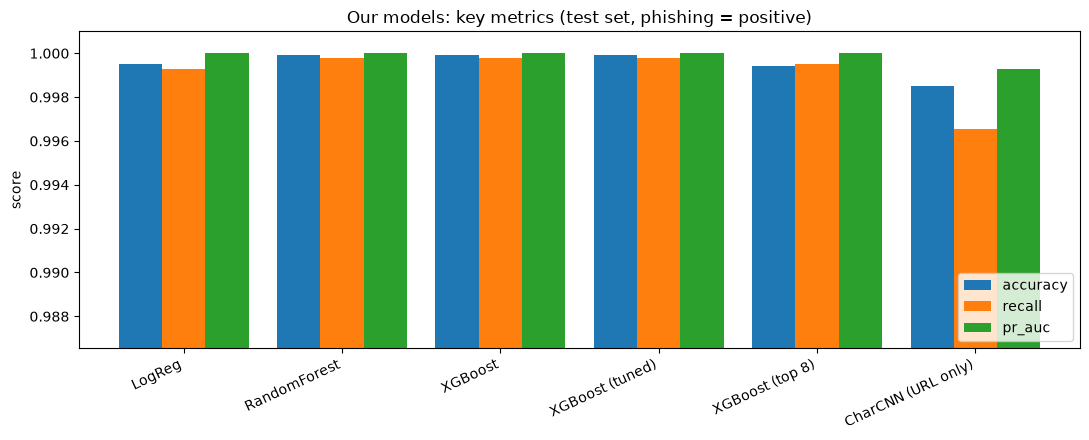

In [20]:
# NB 02's saved tabular metrics (phishing = positive, same exact-Domain
# split as this notebook, so the rows below are directly comparable).
nb02_path = Path("../data/02_classical_results.json")
assert nb02_path.exists(), (
    "Run NB 02 first; it saves 02_classical_results.json this table needs."
)
nb02 = json.loads(nb02_path.read_text())
assert nb02["positive_class"] == "phishing"

tab = pd.DataFrame(nb02["metrics"]).set_index("model")

# Append this notebook's CharCNN result (live variable from above).
char_row = (
    pd.Series(char_result).drop("model").to_frame(char_result["model"]).T
)
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
our = pd.concat([tab, char_row])[metric_cols].astype(float)

print(
    f"NB 02 test rows: {nb02['n_test']:,}   "
    f"CharCNN test rows: {len(y_test):,}  (shared split)\n"
)
print(our.round(4).to_string())

# Graphical empirical comparison (rubric asks for this explicitly).
# Zoom the y-axis since every model is near the ceiling.
plot_metrics = ["accuracy", "recall", "pr_auc"]
lo = float(our[plot_metrics].min().min())

ax = our[plot_metrics].plot.bar(
    figsize=(11, 4.5),
    width=0.82,
    color=["tab:blue", "tab:orange", "tab:green"],
)
ax.set_ylim(max(0.0, lo - 0.01), 1.001)
ax.set_ylabel("score")
ax.set_title("Our models: key metrics (test set, phishing = positive)")
ax.legend(loc="lower right")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Published results in context

Same dataset (PhiUSIIL), directly comparable to our rows above:

| Study | Approach | Reported | Status |
|---|---|---|---|
| Prasad & Chandra (2024), *Computers & Security* 136 (dataset authors) | similarity-index + incremental learning | ~99.2% (incremental) to ~99.8% (batch); one source 99.97% / AUC 1.00 | unverified; secondary sources disagree |
| Pentapalli et al. (2025), arXiv:2504.18636 | TSK fuzzy; excluded `URLSimilarityIndex` as a legitimacy proxy | n/a | qualitative agreement with our leakage call |
| Independent reproductions (Kaggle, small papers) | RF / DT / KNN / LR / XGB / FCNN / BERT | 99.5-100% band across model families | aggregated, unverified individually |
| This project, tuned XGBoost (NB 02) | full leakage-clean feature set | see table above | our result |
| This project, CharCNN (URL only) | raw URL characters only | 0.9985 acc / 0.9993 PR-AUC | our result |

URL-only / lexical literature (other datasets, context only):

| Study | Dataset | Approach | Reported acc | Status |
|---|---|---|---|---|
| Sahingoz et al. (2019), *ESWA* 117 | 73,575 URLs | RF on 39 NLP lexical features | 97.98% | corroborated; firmest external number |
| Yerima & Alzaylaee (2020), arXiv:2004.03960 | own corpus | char-CNN | 98.2% (F1 0.976) | reported (arXiv) |
| Maneriker et al. (2021), *URLTran*, arXiv:2106.05256 | own corpus | BERT on subword URLs | ~96% | reported (arXiv) |
| MiniLM-CNN-LSTM (2024/25), *Technologies* (MDPI) | n/a | hybrid | 98.98% | reported |
| Dubey et al. (2025), arXiv:2512.16717 | n/a | char-CNN + LightGBM | 99.82% | reported (arXiv) |
| Mohammad et al. (2014), *Neural Comput. & Appl.* 25 | own | self-structuring NN | 92-96% (disputed) | unverified; hedge or drop |

These bracket a 97-99% range for URL-only models on harder cross-source
corpora. Our CharCNN lands above that band because PhiUSIIL is more
separable at the raw-string level, not because the architecture is
stronger (see the character-level model section).

Precedents for this notebook's other methods: for the NB 02 imbalance
ablation, Omari et al. (2025), *IJACSA* 16(2), report SMOTE-NC + XGBoost
at 98.0% precision / 98.5% recall. For the clustering, Feng et al. (2022),
*PeerJ CS* 8:e868 (k-medoid on phishing kits, 90.1% TPR) and Zia &
Kalidass (2025), arXiv:2502.13171 (LSH on lexical tokens, 93% on
PhishStorm) frame attack-family clustering as standard practice.

### Where our results land

Against PhiUSIIL, every one of our models sits in the published 99.5-100%
band: LogReg 0.9995, RandomForest 0.9999, XGBoost 1.0000, tuned XGBoost
0.9999, and a top-8-feature model at 0.9993. This reproduces the dataset
authors' range and the independent reproductions across model families.
We are confirming a known ceiling, not producing an outlier.

At four decimals almost everything rounds to ~1.0, so accuracy ordering
is noise. The informative comparison is the CharCNN: 0.9985 accuracy and
0.9993 PR-AUC on the same 46,632-row test split, within 0.0015 accuracy
of the full-feature XGBoost. A model denied `URLSimilarityIndex`, the
page-content flags, and the engineered features, seeing only the raw URL
string, matches models that see all 49 clean features. That is direct
evidence from our own pipeline that PhiUSIIL's separability is in the URL
strings, not just the content columns NB 01 flagged, and it corroborates
the benchmark-leakage critique (Dalton et al., 2025; Das et al., 2019)
rather than only citing it.

Against the URL-only literature, the CharCNN's 0.9985 sits above the
97-99% band those papers report (Sahingoz et al., 2019: 97.98%; Yerima &
Alzaylaee, 2020: 98.2%; URLTran: ~96%). As the character-level model
argued above, this reflects PhiUSIIL being more separable at the
raw-string level than the harder corpora those studies used, not a
stronger architecture. The claim we make is "~99.85% on PhiUSIIL."

The supervised problem is saturated; the useful question is why. The
contribution of this notebook is not a new ceiling number but the
leakage-immune CharCNN and the clustering, which together characterize
what makes the benchmark easy and what kinds of phishing it contains.

## Summary and hand-off

This notebook contributed the leakage-immune model, the unsupervised
analysis, and the literature comparison.

Split. Adopted NB 02's exact-`Domain` `GroupShuffleSplit`
(`test_size=0.2`, `random_state=42`), after confirming the score is
near-invariant to grouping strictness (0.9990-0.9995 across exact,
PaaS-aware, and naive eTLD+1). The CharCNN shares NB 02's 46,632-row test
set, so the SOTA numbers are measured under identical conditions.

Character-level model. A compact CharCNN on the raw URL string only, with
no engineered, content, or similarity features, reached 0.9985 accuracy,
0.9999 precision, 0.9965 recall, and 0.9993 PR-AUC (1 false positive, 69
false negatives), converging in one epoch. It ties the full-feature
tabular models to within 0.0015 accuracy, which shows PhiUSIIL's
separability lives in the URL strings themselves, not only the
page-content columns.

Clustering. KMeans (k=5) partitions the phishing rows into empty-shell
pages (68%), HTTP lookalike stubs (19%), credential-harvesting forms
(12%), an IP-host / obfuscated-URL group (1%), and a 5-row outlier. The
structure is soft: silhouettes ~0.15, PCA's first two components explain
22.9% of variance, and HDBSCAN finds 25 kit-level micro-clusters with 30%
noise. KMeans is the descriptive lens, HDBSCAN the validity check.

SOTA. All five supervised models fall in the published 99.5-100% PhiUSIIL
band. The informative result is the CharCNN near-tie, which locates why
the benchmark is easy rather than adding another ceiling number.

Hand-off. Metrics are saved to `data/03_charcnn_cluster_results.json`. For
the report, lean on PR-AUC and raw error counts rather than accuracy,
since four-decimal accuracy ordering is noise at this ceiling. The figures
worth carrying into the paper are the CharCNN confusion matrix
(Character-level model section) and the PCA/HDBSCAN views (Clustering
section).

In [21]:
nb03_out = {
    "notebook": "03",
    "positive_class": "phishing",
    "split": {
        "grouping": "exact Domain (matches NB 02)",
        "test_size": 0.2,
        "random_state": 42,
        "n_test": int(len(y_test)),
        "grouping_invariance": {
            "exact_domain": 0.9995,
            "paas_aware_etld1": 0.9993,
            "naive_etld1": 0.9990,
        },
    },
    "charcnn": {
        "description": "char-level CNN on raw URL string only, no "
        "engineered/content/similarity features",
        "max_len": int(MAX_LEN),
        "vocab_size": int(len(vocab)),
        "n_params": int(n_params),
        "metrics": {
            k: float(v) for k, v in char_result.items() if k != "model"
        },
        "confusion_matrix": confusion_matrix(y_test, test_pred).tolist(),
    },
    "clustering": {
        "algorithm": "KMeans",
        "k": int(K_FAMILIES),
        "n_phishing_rows": int(Xp.shape[0]),
        "silhouette_k2": 0.4373,
        "silhouette_k5": 0.1540,
        "families": {
            FAMILY_NAMES[c]: int(sizes[c]) for c in range(K_FAMILIES)
        },
        "hdbscan_check": {
            "sample_size": int(len(sub)),
            "clusters": int(n_clusters),
            "noise_fraction": float(noise),
        },
    },
    "our_models_vs_literature": {
        "our_models": our.round(4)
        .reset_index()
        .rename(columns={"index": "model"})
        .to_dict(orient="records"),
        "phiusiil_published_band": "99.5-100%",
        "url_only_literature_band": "97-99% (other corpora)",
    },
}

out_path = Path("../data/03_charcnn_cluster_results.json")
out_path.write_text(json.dumps(nb03_out, indent=2))
print(f"saved {out_path}")
print(
    f"  charcnn: {nb03_out['charcnn']['metrics']['accuracy']:.4f} acc, "
    f"{nb03_out['charcnn']['metrics']['pr_auc']:.4f} PR-AUC"
)
print(f"  families: {nb03_out['clustering']['families']}")

saved ../data/03_charcnn_cluster_results.json
  charcnn: 0.9985 acc, 0.9993 PR-AUC
  families: {'empty-shell (68%)': 68743, 'outlier long-URL (5)': 5, 'IP-host / obfuscated (1%)': 1133, 'credential forms (12%)': 11809, 'HTTP lookalike stubs (19%)': 18830}
